In [ ]:
# Use this if your running this on colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# Load Data

In [ ]:
DS_TRAIN = "/content/drive/MyDrive/Colab Notebooks/CMPE258_FinalProject/tft_ready_train.csv"
DS_TEST = "/content/drive/MyDrive/Colab Notebooks/CMPE258_FinalProject/tft_ready_test.csv"
DS_VAL = "/content/drive/MyDrive/Colab Notebooks/CMPE258_FinalProject/tft_ready_val.csv"

# Load CSV files
train = pd.read_csv(DS_TRAIN,parse_dates=["date"])
test = pd.read_csv(DS_TEST,parse_dates=["date"])
val = pd.read_csv(DS_VAL,parse_dates=["date"])

In [ ]:
train.head()

,date,ticker,logvol_t,target_logvol_t+1,target_logvol_t+5,target_logvol_t+22,weekday,is_month_end,is_opex,is_holiday_eve,...,roll_std_ret_132d,roll_mean_vol_132d,roll_std_vol_132d,roll_mean_ret_252d,roll_std_ret_252d,roll_mean_vol_252d,roll_std_vol_252d,pca_vol_cs_1,pca_vol_cs_2,pca_vol_cs_3
0,2011-01-11,GLD,-5.070120,-5.174413,-4.311878,-3.344378,1,0,0,0,...,0.009368,0.006232,0.002946,0.000685,0.010444,0.006980,0.003172,-0.189073,0.922351,-0.811921
1,2011-01-12,GLD,-5.174413,-4.853728,-4.330529,-3.352055,2,0,0,0,...,0.009247,0.006234,0.002946,0.000792,0.010357,0.006945,0.003130,2.027990,1.011525,0.279239
2,2011-01-13,GLD,-4.853728,-4.963198,-4.457583,-3.374136,3,0,0,0,...,0.009214,0.006241,0.002943,0.000771,0.010345,0.006919,0.003113,0.666903,-0.005867,2.288776
3,2011-01-14,GLD,-4.963198,-5.450606,-4.434396,-3.371583,4,0,0,1,...,0.009257,0.006241,0.002943,0.000712,0.010367,0.006911,0.003109,2.124020,0.849803,0.386406
4,2011-01-18,GLD,-5.450606,-5.419435,-4.368734,-3.374667,1,0,0,0,...,0.009276,0.006262,0.002938,0.000713,0.010365,0.006900,0.003103,2.066790,0.059928,-0.236948


In [ ]:
print(train.shape, val.shape, test.shape)

(7000, 43) (1972, 43) (4992, 43)


## Split Data

In [ ]:
TARGET = "target_logvol_t+1"

exclude = ["date", "ticker",
           "target_logvol_t+1", "target_logvol_t+5", "target_logvol_t+22"]

features = [c for c in train.columns if c not in exclude]

In [ ]:
X_train = train[features]
y_train = train[TARGET]

X_val   = val[features]
y_val   = val[TARGET]

X_test  = test[features]
y_test  = test[TARGET]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)

X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


# Gradient Boosted Trees

In [ ]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_s, label=y_train)
dval   = xgb.DMatrix(X_val_s,   label=y_val)

params = dict(
    objective="reg:squarederror",
    eta=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    lambda_=1.0,
    seed=42
)

watchlist = [(dtrain, "train"), (dval, "val")]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=watchlist,
    early_stopping_rounds=50,
    verbose_eval=True
)


[0]	train-rmse:0.49877	val-rmse:0.57403
[1]	train-rmse:0.49325	val-rmse:0.56791
[2]	train-rmse:0.48805	val-rmse:0.56145
[3]	train-rmse:0.48309	val-rmse:0.55475
[4]	train-rmse:0.47842	val-rmse:0.55039
[5]	train-rmse:0.47378	val-rmse:0.54504
[6]	train-rmse:0.46934	val-rmse:0.53896
[7]	train-rmse:0.46513	val-rmse:0.53342
[8]	train-rmse:0.46104	val-rmse:0.52932
[9]	train-rmse:0.45714	val-rmse:0.52393
[10]	train-rmse:0.45343	val-rmse:0.51913
[11]	train-rmse:0.44988	val-rmse:0.51505
[12]	train-rmse:0.44650	val-rmse:0.51141
[13]	train-rmse:0.44321	val-rmse:0.50698


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [03:48:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "lambda_" } are not used.

  self.starting_round = model.num_boosted_rounds()


[14]	train-rmse:0.44005	val-rmse:0.50167
[15]	train-rmse:0.43706	val-rmse:0.49789
[16]	train-rmse:0.43423	val-rmse:0.49395
[17]	train-rmse:0.43144	val-rmse:0.49127
[18]	train-rmse:0.42880	val-rmse:0.48790
[19]	train-rmse:0.42628	val-rmse:0.48438
[20]	train-rmse:0.42388	val-rmse:0.48090
[21]	train-rmse:0.42147	val-rmse:0.47812
[22]	train-rmse:0.41916	val-rmse:0.47583
[23]	train-rmse:0.41706	val-rmse:0.47386
[24]	train-rmse:0.41503	val-rmse:0.47094
[25]	train-rmse:0.41303	val-rmse:0.46856
[26]	train-rmse:0.41107	val-rmse:0.46621
[27]	train-rmse:0.40918	val-rmse:0.46421
[28]	train-rmse:0.40743	val-rmse:0.46163
[29]	train-rmse:0.40572	val-rmse:0.45909
[30]	train-rmse:0.40399	val-rmse:0.45755
[31]	train-rmse:0.40237	val-rmse:0.45552
[32]	train-rmse:0.40078	val-rmse:0.45428
[33]	train-rmse:0.39920	val-rmse:0.45238
[34]	train-rmse:0.39775	val-rmse:0.45094
[35]	train-rmse:0.39637	val-rmse:0.44966
[36]	train-rmse:0.39501	val-rmse:0.44839
[37]	train-rmse:0.39366	val-rmse:0.44740
[38]	train-rmse:

In [ ]:
preds_test = model.predict(xgb.DMatrix(X_test_s))

# Evaluation & Results

### Root Mean Squared Error

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, preds_test)
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 0.4028226665712143


### QLIKE Score

In [ ]:
v_true = np.exp(2 * y_test)        # true variance
v_pred = np.exp(2 * preds_test)    # predicted variance

qlike = np.mean(np.log(v_pred) + v_true / v_pred)
print("Test QLIKE:", qlike)

Test QLIKE: -8.649369179775166


### Feature Importance

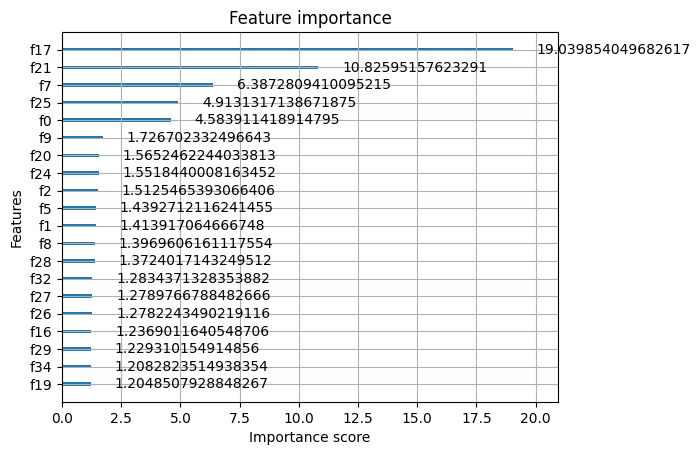

In [ ]:
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.show()


In [ ]:
for H in [1, 5, 22]:
    TARGET = f"target_logvol_t+{H}"
    # define exclude, features, fit model, compute RMSE/QLIKE...


In [ ]:
sigma_pred = np.exp(preds_test)        # forecast σ_t+1
print(sigma_pred)

[0.00451822 0.00335797 0.00354226 ... 0.00580828 0.00509726 0.00511861]
